<a href="https://colab.research.google.com/github/Ezeq31/Ezeq31/blob/main/04-Data-Wrangling/Guided-Project/Demo_Chapters_3_and_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Combined Demo: Chapters 3 & 4
## From Python Foundations to Data Wrangling

**CAI1001C — AI Thinking: A Hands-On Introduction to Artificial Intelligence**

---

### Tonight's Game Plan

We're going to build skills in two connected acts:

| Act | Chapter | What We're Doing | Time |
|-----|---------|-----------------|------|
| **Act 1** | Ch. 3 — Python Foundations | Build a mini order tracker from scratch using variables, collections, conditionals, loops, and functions | ~30 min |
| **Act 2** | Ch. 4 — Data Wrangling | Load a real messy dataset of 10,000 orders and clean it with pandas | ~45 min |

**The connection:** In Act 1, we track 5 orders by hand with pure Python. In Act 2, we see what happens when that same business has 10,000 orders — messy, incomplete, full of errors — and we learn to wrangle it.

---

### The Scenario

You help run a small online gift shop that ships specialty items — candles, picture frames, lunch bags, novelty signs — to customers across Europe. Business has been booming, but the data is a mess.

**Act 1:** You'll build a simple order tracker in pure Python, handling a handful of orders the way a small shop owner might.

**Act 2:** The real shop has been operating for over a year and has hundreds of thousands of transactions saved in a spreadsheet. We'll load 10,000 of those real orders and discover just how messy real-world data gets — missing customer IDs, cancelled orders mixed in with real ones, zero-dollar prices, duplicate entries, and inconsistent product names.

Let's start small and scale up.

---

# 🍳 Act 1: Python Foundations — The Manual Way

*Building an order tracker from scratch with pure Python*

---

## Part 1: Variables and Data Types

Every order has basic information: an invoice number, a product, a quantity, a price, a customer, and a country. Let's store a single order using variables.

💡 **Remember:** A variable is a named container. The `=` sign means *assign* (store), not "equals" like in math.

In [ ]:
# --- A Single Order ---

invoice_no = "536365"           # str — text, even though it looks like a number
product = "White Hanging Heart T-Light Holder"  # str
quantity = 6                     # int — whole number
unit_price = 2.55                # float — decimal number
customer_id = 17850              # int
country = "United Kingdom"       # str
is_cancelled = False             # bool — True or False

# Calculate the total for this order
order_total = quantity * unit_price

# Display using an f-string
print(f"Invoice: {invoice_no}")
print(f"Product: {product}")
print(f"Quantity: {quantity} x £{unit_price:.2f} = £{order_total:.2f}")
print(f"Customer: {customer_id} ({country})")
print(f"Cancelled: {is_cancelled}")
print(f"\nData types: quantity is {type(quantity).__name__}, "
      f"unit_price is {type(unit_price).__name__}, "
      f"is_cancelled is {type(is_cancelled).__name__}")

### What Just Happened

We stored six pieces of order information using four different data types:

| Variable | Value | Type | Why This Type? |
|----------|-------|------|----------------|
| `invoice_no` | `"536365"` | `str` | It's a label, not a number we'll do math with |
| `quantity` | `6` | `int` | Whole number — you can't order 6.5 candles |
| `unit_price` | `2.55` | `float` | Money needs decimal precision |
| `is_cancelled` | `False` | `bool` | Only two possibilities: cancelled or not |

The fifth type, `None`, will show up in Act 2 when we encounter missing data.

---

## Part 2: Collections — Organizing Multiple Items

One order is fine, but a real shop has many. Let's organize multiple orders using **lists** and **dictionaries**.

💡 **Lists** = ordered items on a shelf (accessed by position). **Dictionaries** = labeled jars (accessed by name).

In [ ]:
# --- A Single Order as a Dictionary ---
# Each key is a label, each value is the data

order_1 = {
    "invoice": "536365",
    "product": "White Hanging Heart T-Light Holder",
    "quantity": 6,
    "unit_price": 2.55,
    "customer_id": 17850,
    "country": "United Kingdom"
}

# Access specific values by key
print(f"Product: {order_1['product']}")
print(f"Price: £{order_1['unit_price']:.2f}")

In [ ]:
# --- Multiple Orders in a List of Dictionaries ---

orders = [
    {
        "invoice": "536365",
        "product": "White Hanging Heart T-Light Holder",
        "quantity": 6,
        "unit_price": 2.55,
        "customer_id": 17850,
        "country": "United Kingdom"
    },
    {
        "invoice": "536366",
        "product": "Hand Warmer Union Jack",
        "quantity": 24,
        "unit_price": 1.85,
        "customer_id": 17850,
        "country": "United Kingdom"
    },
    {
        "invoice": "536367",
        "product": "Assorted Colour Bird Ornament",
        "quantity": 36,
        "unit_price": 1.25,
        "customer_id": 13047,
        "country": "France"
    },
    {
        "invoice": "C536379",
        "product": "Knitted Union Flag Hot Water Bottle",
        "quantity": -1,
        "unit_price": 3.39,
        "customer_id": None,   # <-- Missing customer!
        "country": "United Kingdom"
    },
    {
        "invoice": "536389",
        "product": "Popcorn Holder",
        "quantity": 12,
        "unit_price": 0.85,
        "customer_id": 12583,
        "country": "France"
    }
]

print(f"Total orders loaded: {len(orders)}")
print(f"\nFirst order product: {orders[0]['product']}")
print(f"Last order product: {orders[-1]['product']}")

⚠️ **Notice:** Order 4 (invoice `C536379`) has two problems — a negative quantity and a missing customer ID (`None`). Those are real issues we'll see at scale in Act 2.

---

### 🛑 Checkpoint 1

You should see:
- `Total orders loaded: 5`
- The first order is the T-Light Holder, the last is the Popcorn Holder
- Order 4 has `None` for customer_id and a negative quantity

If that matches, you're good. Let's teach our code to make decisions.

---

## Part 3: Conditionals — Making Decisions

A real business needs logic: Is this order valid? Should a discount apply? Is the customer a bulk buyer? Let's write rules.

In [ ]:
# --- Validate a Single Order ---

test_order = orders[3]   # The suspicious one (C536379)

print(f"Checking order {test_order['invoice']}...")
print(f"  Quantity: {test_order['quantity']}")
print(f"  Customer ID: {test_order['customer_id']}")

# Check if invoice starts with 'C' (cancellation)
if test_order['invoice'].startswith('C'):
    print("  ⚠️ This is a CANCELLATION (invoice starts with C)")

# Check for missing customer
if test_order['customer_id'] is None:
    print("  ⚠️ MISSING customer ID")

# Check for negative quantity
if test_order['quantity'] < 0:
    print("  ⚠️ NEGATIVE quantity — likely a return")
elif test_order['quantity'] == 0:
    print("  ⚠️ ZERO quantity — no items")
else:
    print("  ✅ Quantity looks good")

In [ ]:
# --- Discount Logic Based on Quantity ---

valid_order = orders[2]  # France order, 36 items
qty = valid_order['quantity']
price = valid_order['unit_price']

# Tiered discount
if qty >= 50:
    discount = 0.15      # 15% for large bulk
    tier = "Gold"
elif qty >= 25:
    discount = 0.10      # 10% for medium bulk
    tier = "Silver"
elif qty >= 10:
    discount = 0.05      # 5% for small bulk
    tier = "Bronze"
else:
    discount = 0.0
    tier = "Standard"

subtotal = qty * price
discount_amount = subtotal * discount
final_total = subtotal - discount_amount

print(f"Order: {qty}x {valid_order['product']}")
print(f"Tier: {tier} ({discount*100:.0f}% off)")
print(f"Subtotal: £{subtotal:.2f}")
print(f"Discount: -£{discount_amount:.2f}")
print(f"Final: £{final_total:.2f}")

### What Just Happened

We used `if`/`elif`/`else` two ways:

1. **Validation** — checking for problems (cancellations, missing data, negatives)
2. **Business logic** — applying discount tiers based on quantity

Key reminders:
- `=` assigns a value. `==` compares. Don't mix them up.
- `is None` checks for missing data (not `== None`).
- `.startswith('C')` is a string method — handy for pattern checking.
- Only ONE branch runs: the first condition that's `True`.

---

## Part 4: Loops — Processing All Orders at Once

We validated one order. But what about all five? That's where loops come in — write the logic once, apply it to every item.

In [ ]:
# --- Loop Through All Orders and Calculate Totals ---

total_revenue = 0
valid_count = 0
problem_count = 0

print("Processing all orders...\n")

for order in orders:
    inv = order['invoice']
    qty = order['quantity']
    price = order['unit_price']
    line_total = qty * price

    # Check for problems
    if qty <= 0 or order['customer_id'] is None:
        print(f"  ❌ {inv}: SKIPPED (qty={qty}, customer={order['customer_id']})")
        problem_count += 1
        continue   # Skip to next order

    # Valid order — add to revenue
    total_revenue += line_total
    valid_count += 1
    print(f"  ✅ {inv}: {qty}x @ £{price:.2f} = £{line_total:.2f}")

print(f"\n{'='*40}")
print(f"Valid orders: {valid_count}")
print(f"Problem orders: {problem_count}")
print(f"Total revenue: £{total_revenue:.2f}")

In [ ]:
# --- Count Orders by Country (Accumulator Pattern) ---

country_counts = {}   # Empty dictionary to fill

for order in orders:
    c = order['country']

    if c in country_counts:
        country_counts[c] += 1        # Already seen — add 1
    else:
        country_counts[c] = 1         # First time — start at 1

print("Orders by country:")
for country, count in country_counts.items():
    print(f"  {country}: {count}")

### 🛑 Checkpoint 2

You should see:
- 4 valid orders, 1 skipped (the cancellation with no customer)
- Total revenue around £105.30
- United Kingdom: 3, France: 2

Notice the patterns we used:
- **Accumulator** — `total_revenue += line_total`
- **Counter** — `valid_count += 1`
- **Skip bad data** — `continue` jumps to the next iteration
- **Build a dictionary** — counting countries on the fly

---

## Part 5: Functions — Reusable Code Blocks

We've been writing the same validation and calculation logic inline. Let's wrap it into **functions** so we can reuse it cleanly.

In [18]:
# --- Function 1: Validate an Order ---

def is_valid_order(order):
    """
    Check if an order is valid for revenue calculations.

    Parameters:
        order (dict): A single order dictionary

    Returns:
        bool: True if valid, False if it should be excluded
    """
    # Cancellations (invoice starts with C)
    if str(order['invoice']).startswith('C'):
        return False

    # Missing customer
    if order['customer_id'] is None:
        return False

    # Non-positive quantity or price
    if order['quantity'] <= 0 or order['unit_price'] <= 0:
        return False

    return True


# --- Function 2: Calculate Line Total with Discount ---

def calculate_line_total(quantity, unit_price):
    """
    Calculate order total with bulk discount applied.

    Parameters:
        quantity (int): Number of items
        unit_price (float): Price per item

    Returns:
        tuple: (subtotal, discount_amount, final_total)
    """
    subtotal = quantity * unit_price

    if quantity >= 50:
        discount = 0.15
    elif quantity >= 25:
        discount = 0.10
    elif quantity >= 10:
        discount = 0.05
    else:
        discount = 0.0

    discount_amount = subtotal * discount
    final_total = subtotal - discount_amount

    return subtotal, discount_amount, final_total


# --- Function 3: Process All Orders ---

def process_orders(order_list):
    """
    Process a list of orders: validate, calculate, and summarize.

    Parameters:
        order_list (list): List of order dictionaries

    Returns:
        dict: Summary with total_revenue, valid_count, skipped_count
    """
    total_revenue = 0
    valid_count = 0
    skipped_count = 0

    for order in order_list:
        if not is_valid_order(order):
            skipped_count += 1
            continue

        sub, disc, final = calculate_line_total(order['quantity'], order['unit_price'])
        total_revenue += final
        valid_count += 1

    return {
        "total_revenue": round(total_revenue, 2),
        "valid_orders": valid_count,
        "skipped_orders": skipped_count
    }

In [20]:
# --- Use Our Functions ---

summary = process_orders(orders)

print("=" * 40)
print("  ORDER PROCESSING SUMMARY")
print("=" * 40)
print(f"  Valid orders:   {summary['valid_orders']}")
print(f"  Skipped:        {summary['skipped_orders']}")
print(f"  Total revenue:  £{summary['total_revenue']:.2f}")
print("=" * 40)

  ORDER PROCESSING SUMMARY
  Valid orders:   4
  Skipped:        1
  Total revenue:  £107.67


### 🛑 Checkpoint 3 — End of Act 1

We just built a working order tracker using **every major Python concept from Chapter 3**:

| Concept | Where We Used It |
|---------|------------------|
| Variables & Data Types | Stored order info (str, int, float, bool, None) |
| Dictionaries | Each order is a dict with labeled fields |
| Lists | All orders stored in a list of dicts |
| Conditionals | Validation rules, discount tiers |
| Loops | Processed every order with `for` |
| Functions | Wrapped logic into reusable `def` blocks |

**This works for 5 orders.** But the real shop has over half a million transactions in a spreadsheet. We can't type those into dictionaries by hand. We need a tool that loads, explores, and cleans data at scale.

That tool is **pandas**. Let's go.

---

# 🔧 Act 2: Data Wrangling — The Real World at Scale

*Same gift shop. 10,000 real orders. Real mess.*

---

The dataset we're about to load is real transactional data from a UK-based online gift retailer, spanning December 2010 through December 2011. The full file has over 541,000 records. We'll sample 10,000 to keep things fast.

**Fair warning:** This data was NOT cleaned before we got it. It has all the problems Lucia's restaurant had in the chapter reading — and then some.

---

## Part 6: Setup and Load the Data

In [23]:
# --- Setup: Install dependencies and import libraries ---
# Run this cell. Do not modify.

!pip install openpyxl -q

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"pandas version: {pd.__version__}")

Libraries loaded successfully!
pandas version: 2.2.2


In [24]:
# --- Load the Dataset from GitHub ---
# Run this cell. Do not modify.

# Convert the GitHub blob URL to a raw download URL
url = ("https://docs.google.com/spreadsheets/d/18fPwka92Aodl7VhQICk73dJspTxxsT-K/export?format=xlsx")

# Load the Excel file
print("Loading dataset from GitHub (this may take a moment)...")
df_full = pd.read_excel(url)
print(f"Full dataset loaded: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")

# Sample 10,000 rows for class (random_state ensures everyone gets the same sample)
df = df_full.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Working sample: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nReady to explore!")

Loading dataset from GitHub (this may take a moment)...
Full dataset loaded: 541,909 rows, 8 columns
Working sample: 10,000 rows, 8 columns

Ready to explore!


## Part 7: Explore the Data

💡 **The Kitchen Inspection:** Before you clean anything, you walk the kitchen first. Run these four commands on every new dataset — make it muscle memory.

---

In [25]:
# 1. What does the data look like?
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom
5,576200,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-11-14 12:14:00,2.95,15572.0,United Kingdom
6,577076,22614,PACK OF 12 SPACEBOY TISSUES,12,2011-11-17 15:08:00,0.39,14362.0,United Kingdom
7,568909,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,12,2011-09-29 13:38:00,1.25,16818.0,United Kingdom
8,578072,21109,LARGE CAKE TOWEL CHOCOLATE SPOTS,1,2011-11-22 16:02:00,6.75,17759.0,United Kingdom
9,560491,23297,SET 40 HEART SHAPE PETIT FOUR CASES,2,2011-07-19 10:51:00,1.65,12415.0,Australia


In [26]:
# 2. How big is it, and what types do we have?
print("Shape:", df.shape)
print()
df.info()

Shape: (10000, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    10000 non-null  object        
 1   StockCode    10000 non-null  object        
 2   Description  9969 non-null   object        
 3   Quantity     10000 non-null  int64         
 4   InvoiceDate  10000 non-null  datetime64[ns]
 5   UnitPrice    10000 non-null  float64       
 6   CustomerID   7484 non-null   float64       
 7   Country      10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 625.1+ KB


In [27]:
# 3. Statistical summary of numerical columns
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,10000.000000,10000,10000.000000,7484.000000
mean,9.902300,2011-07-04 06:05:27.197999872,3.752336,15251.783805
min,-1350.000000,2010-12-01 08:26:00,0.000000,12347.000000
25%,1.000000,2011-03-27 11:50:00,1.250000,13882.750000
50%,3.000000,2011-07-19 13:01:00,2.080000,15061.000000
75%,10.000000,2011-10-18 21:07:30,4.130000,16781.250000
max,2880.000000,2011-12-09 12:50:00,1867.860000,18287.000000
std,49.498622,NaN,21.785467,1718.939462


In [28]:
# 4. What countries are represented?
print(f"Unique countries: {df['Country'].nunique()}")
print()
print(df['Country'].value_counts().head(10))

Unique countries: 34

Country
United Kingdom    9111
Germany            188
France             182
EIRE               153
Spain               49
Netherlands         44
Belgium             37
Switzerland         32
Portugal            30
Norway              24
Name: count, dtype: int64


### 🛑 Checkpoint 4 — What Did You Notice?

Before reading ahead, look at the outputs and try to spot problems:

- In `.info()`: Do all columns have the same number of non-null values? Which column has the most missing data?
- In `.describe()`: Look at the **min** values for `Quantity` and `UnitPrice`. Do those make sense for a real shop?
- Do any `InvoiceNo` values start with `C`?

Let's dig into each of these problems.

---

## Part 8: Find and Handle Missing Values

Missing data = `NaN` ("Not a Number") in pandas. Let's find out how much is missing.

In [44]:
# Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*40)

# Show as percentages
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print("\nMissing value percentages:")
print(missing_pct)

Missing values per column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Month          0
dtype: int64


Missing value percentages:
InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalPrice     0.0
Month          0.0
dtype: float64


💡 **Decision Time:**

- **Description** — A small number of product names are missing. We'll fill with `'Unknown Product'`.
- **CustomerID** — About 25% missing. This is a LOT. We won't drop these rows (we'd lose too much data), but we'll fill with `0` so pandas doesn't choke on NaN during calculations. We'll flag these as unknown customers.

⚠️ **Remember from the reading:** Use the median for numerical fills (not the mean) when outliers are present. For CustomerID, we're using 0 as a placeholder, not a statistical fill — it just means "we don't know who this customer is."

In [30]:
# Fill missing Descriptions
df['Description'] = df['Description'].fillna('Unknown Product')

# Fill missing CustomerIDs with 0 (unknown customer placeholder)
df['CustomerID'] = df['CustomerID'].fillna(0).astype(int)

# Verify — should be zero missing values now
print("Missing values after cleanup:")
print(df.isnull().sum())

Missing values after cleanup:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### 🛑 Checkpoint 5

All columns should now show `0` missing values. If not, re-run the cells above.

---

## Part 9: Remove Duplicates

Sometimes the same transaction gets recorded more than once. Let's check.

In [31]:
# How many exact duplicate rows?
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

# Remove them
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Removed:     {rows_before - rows_after:,}")

Duplicate rows found: 1
Rows before: 10,000
Rows after:  9,999
Removed:     1


## Part 10: Filter Out Bad Data

Remember from Act 1 — some invoices start with `C` (cancellations) and some quantities are negative. Let's find and remove these.

In [46]:
# --- Find Cancellations (Invoice starts with 'C') ---
# First, make sure InvoiceNo is a string
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

cancellations = df[df['InvoiceNo'].str.startswith('C')]
print(f"Cancellation rows: {len(cancellations)}")
print(cancellations[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice']].head())

Cancellation rows: 0
Empty DataFrame
Columns: [InvoiceNo, Description, Quantity, UnitPrice]
Index: []


In [47]:
# --- Find Other Problems ---

neg_qty = df[df['Quantity'] <= 0]
print(f"Rows with non-positive Quantity: {len(neg_qty)}")

zero_price = df[df['UnitPrice'] <= 0]
print(f"Rows with non-positive UnitPrice: {len(zero_price)}")

Rows with non-positive Quantity: 0
Rows with non-positive UnitPrice: 0


In [50]:
# --- Remove All Bad Data ---

rows_before = len(df)

# Keep only non-cancelled orders
df = df[~df['InvoiceNo'].str.startswith('C')]

# Keep only positive quantities
df = df[df['Quantity'] > 0]

# Keep only positive prices
df = df[df['UnitPrice'] > 0]

rows_after = len(df)

print(f"Rows before filtering: {rows_before:,}")
print(f"Rows after filtering:  {rows_after:,}")
print(f"Removed:               {rows_before - rows_after:,}")

Rows before filtering: 9,783
Rows after filtering:  9,783
Removed:               0


### 🛑 Checkpoint 6

We should have removed cancellations, negative quantities, and zero-dollar items. Verify:
- `df['Quantity'].min()` should be > 0
- `df['UnitPrice'].min()` should be > 0
- No InvoiceNo values should start with 'C'

---

In [51]:
# Quick verification
print(f"Min Quantity:  {df['Quantity'].min()}")
print(f"Min UnitPrice: {df['UnitPrice'].min()}")
print(f"Cancellations remaining: {df['InvoiceNo'].str.startswith('C').sum()}")
print("\n✅ All checks passed!" if df['Quantity'].min() > 0
      and df['UnitPrice'].min() > 0
      and df['InvoiceNo'].str.startswith('C').sum() == 0
      else "\n❌ Something still needs fixing")

Min Quantity:  1
Min UnitPrice: 0.04
Cancellations remaining: 0

✅ All checks passed!


## Part 11: Standardize Text

Product descriptions are often inconsistent — different capitalization, extra spaces. Let's check and fix.

In [52]:
# Look at descriptions for a common product
sample_code = df['StockCode'].value_counts().index[0]
print(f"Most common StockCode: {sample_code}")
print(f"\nDescriptions used for this product:")
print(df[df['StockCode'] == sample_code]['Description'].unique())

Most common StockCode: 85123A

Descriptions used for this product:
['white hanging heart t-light holder']


In [55]:
# Standardize: lowercase and strip whitespace
df['Description'] = df['Description'].str.lower().str.strip()

# Verify — same StockCode should now have consistent descriptions
print(f"Descriptions for {sample_code} after cleanup:")
print(df[df['StockCode'] == sample_code]['Description'].unique())

Descriptions for 85123A after cleanup:
['white hanging heart t-light holder']


## Part 12: Transform and Analyze

Our data is clean. Now let's create new columns and answer real business questions.

---

In [56]:
# --- Create a TotalPrice column ---

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("New column added!")
print(df[['Description', 'Quantity', 'UnitPrice', 'TotalPrice']].head(10))

New column added!
                           Description  Quantity  UnitPrice  TotalPrice
0       hanging jam jar t-light holder        24       0.85       20.40
1                   gold fishing gnome         4       6.95       27.80
2          set/6 red spotty paper cups         4       0.65        2.60
3     pack 3 boxes christmas panettone         3       1.95        5.85
4                       retrospot lamp         2       9.95       19.90
5    wooden picture frame white finish         2       2.95        5.90
6          pack of 12 spaceboy tissues        12       0.39        4.68
7  christmas star wish list chalkboard        12       1.25       15.00
8     large cake towel chocolate spots         1       6.75        6.75
9  set 40 heart shape petit four cases         2       1.65        3.30


In [57]:
# --- Top 10 Products by Revenue ---

top_products = (df.groupby('Description')['TotalPrice']
                .sum()
                .sort_values(ascending=False)
                .head(10))

print("Top 10 Products by Total Revenue:\n")
for product, revenue in top_products.items():
    print(f"  £{revenue:>10,.2f}  {product}")

Top 10 Products by Total Revenue:

  £  3,648.48  gin + tonic diet metal sign
  £  3,055.72  jumbo bag red retrospot
  £  2,116.05  party bunting
  £  1,827.44  regency cakestand 3 tier
  £  1,799.56  jumbo bag strawberry
  £  1,732.46  alarm clock bakelike pink
  £  1,706.15  feltcraft doll molly
  £  1,513.86  chocolate hot water bottle
  £  1,195.10  white hanging heart t-light holder
  £  1,125.87  alarm clock bakelike ivory


In [58]:
# --- Revenue by Country ---

country_revenue = (df.groupby('Country')['TotalPrice']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

print("Top 10 Countries by Revenue:\n")
for country, revenue in country_revenue.items():
    print(f"  £{revenue:>10,.2f}  {country}")

Top 10 Countries by Revenue:

  £150,790.66  United Kingdom
  £  6,090.12  EIRE
  £  4,975.25  Netherlands
  £  4,356.67  Germany
  £  3,892.29  France
  £  1,676.48  Australia
  £    891.70  Spain
  £    872.38  Norway
  £    710.70  Portugal
  £    705.17  Switzerland


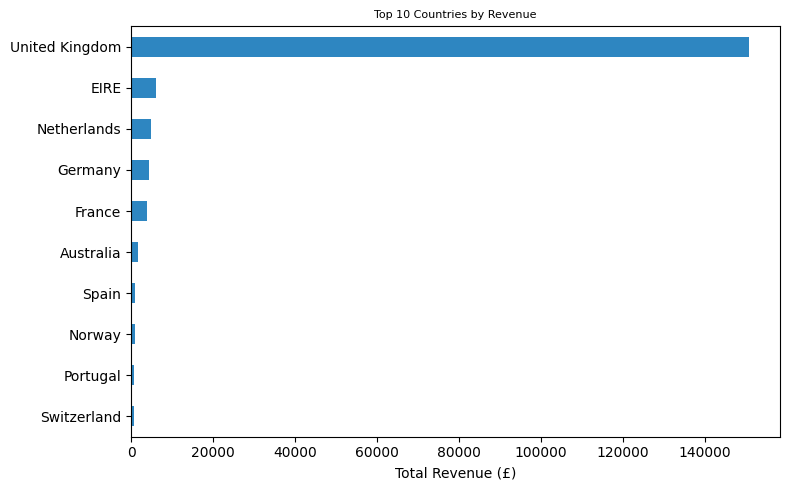

In [62]:
# --- Quick Visualization: Top 10 Countries ---

country_revenue.plot(kind='barh', figsize=(8, 5), color='#2E86C1')
plt.title('Top 10 Countries by Revenue', fontsize=8)
plt.xlabel('Total Revenue (£)')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

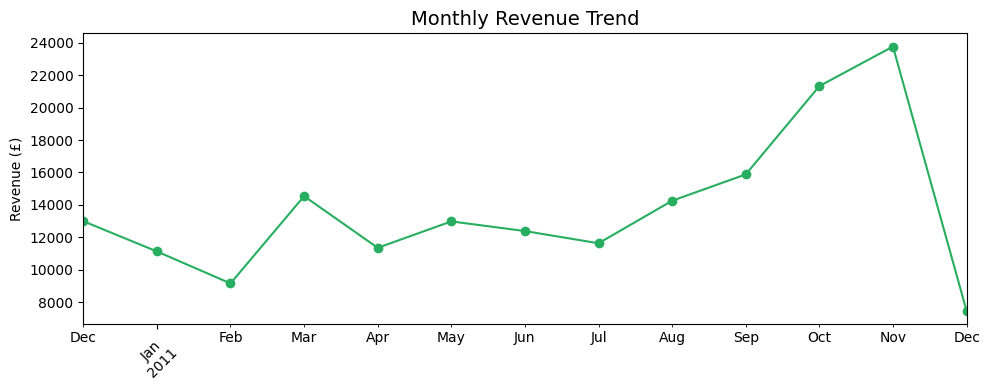

In [63]:
# --- Orders Over Time ---

# Convert InvoiceDate to proper datetime if it isn't already
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month for grouping
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

monthly_revenue.plot(kind='line', figsize=(10, 4), marker='o', color='#27AE60')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.ylabel('Revenue (£)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 13: Final Clean Data Summary

In [64]:
# --- Final Report ---

print("=" * 50)
print("  CLEAN DATA SUMMARY")
print("=" * 50)
print(f"  Rows:             {df.shape[0]:,}")
print(f"  Columns:          {df.shape[1]}")
print(f"  Missing values:   {df.isnull().sum().sum()}")
print(f"  Duplicate rows:   {df.duplicated().sum()}")
print(f"  Price range:      £{df['UnitPrice'].min():.2f} – £{df['UnitPrice'].max():.2f}")
print(f"  Quantity range:   {df['Quantity'].min()} – {df['Quantity'].max()}")
print(f"  Total revenue:    £{df['TotalPrice'].sum():,.2f}")
print(f"  Unique products:  {df['Description'].nunique():,}")
print(f"  Unique customers: {df['CustomerID'].nunique():,}")
print(f"  Countries:        {df['Country'].nunique()}")
print("=" * 50)

  CLEAN DATA SUMMARY
  Rows:             9,783
  Columns:          10
  Missing values:   0
  Duplicate rows:   0
  Price range:      £0.04 – £308.82
  Quantity range:   1 – 2880
  Total revenue:    £178,904.91
  Unique products:  2,411
  Unique customers: 2,406
  Countries:        34


---

## 🎯 What We Built Tonight

### Act 1 — Python Foundations (The Manual Way)

We built a mini order tracker from scratch using every core concept from Chapter 3:

| Concept | What We Did |
|---------|-------------|
| **Variables & Types** | Stored order data as str, int, float, bool, None |
| **Dictionaries** | Structured each order with labeled fields |
| **Lists** | Held multiple orders in one collection |
| **Conditionals** | Validated orders, applied discount tiers |
| **Loops** | Processed all orders, counted by country |
| **Functions** | Wrapped logic into reusable `def` blocks |

### Act 2 — Data Wrangling (The pandas Way)

We loaded 10,000 real orders and cleaned them using the full wrangling pipeline from Chapter 4:

| Step | What We Did | Key Command |
|------|-------------|-------------|
| **Explore** | Inspected shape, types, stats, sample rows | `.shape`, `.info()`, `.describe()`, `.head()` |
| **Missing Values** | Found and filled NaN values | `.isnull().sum()`, `.fillna()` |
| **Duplicates** | Found and removed exact duplicate rows | `.duplicated()`, `.drop_duplicates()` |
| **Bad Data** | Filtered cancellations, negatives, zeros | Boolean filtering with `[]` |
| **Text Cleanup** | Standardized product descriptions | `.str.lower().str.strip()` |
| **Transform** | Created TotalPrice, grouped by country/product | New columns, `.groupby()` |
| **Visualize** | Bar chart and line chart from clean data | `matplotlib` |

### The Big Takeaway

Python foundations (Act 1) are the building blocks. pandas (Act 2) is what lets you apply those same ideas — filtering, validating, calculating — at a scale no human could handle manually. Together, they're the foundation of every AI and data science project.

**Next up:** Chapter 5 — Data Analysis, Visualization, and AI Modeling. The kitchen is clean. Time to cook.

---

*Demo complete!* 🎉